In [56]:
install.packages(
  c("ggplot2", "moments"),
  repos = "https://cloud.r-project.org"
)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [57]:
library(ggplot2)
library(moments)

In [58]:
url <- "https://raw.githubusercontent.com/allisonhorst/palmerpenguins/main/inst/extdata/penguins.csv"

penguins <- read.csv(url)

head(penguins)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
,<chr>,<chr>,<dbl>,<dbl>,<int>,<int>,<chr>,<int>
1,Adelie,Torgersen,39.1,18.7,181,3750,male,2007
2,Adelie,Torgersen,39.5,17.4,186,3800,female,2007
3,Adelie,Torgersen,40.3,18.0,195,3250,female,2007
4,Adelie,Torgersen,NA,NA,NA,NA,NA,2007
5,Adelie,Torgersen,36.7,19.3,193,3450,female,2007
6,Adelie,Torgersen,39.3,20.6,190,3650,male,2007


In [59]:
dim(penguins)

str(penguins)

summary(penguins)

[1] 344   8

'data.frame':	344 obs. of  8 variables:
 $ species          : chr  "Adelie" "Adelie" "Adelie" "Adelie" ...
 $ island           : chr  "Torgersen" "Torgersen" "Torgersen" "Torgersen" ...
 $ bill_length_mm   : num  39.1 39.5 40.3 NA 36.7 39.3 38.9 39.2 34.1 42 ...
 $ bill_depth_mm    : num  18.7 17.4 18 NA 19.3 20.6 17.8 19.6 18.1 20.2 ...
 $ flipper_length_mm: int  181 186 195 NA 193 190 181 195 193 190 ...
 $ body_mass_g      : int  3750 3800 3250 NA 3450 3650 3625 4675 3475 4250 ...
 $ sex              : chr  "male" "female" "female" NA ...
 $ year             : int  2007 2007 2007 2007 2007 2007 2007 2007 2007 2007 ...


      species          island    bill_length_mm  bill_depth_mm  
 Length   :344   Length   :344   Min.   :32.10   Min.   :13.10  
 N.unique :  3   N.unique :  3   1st Qu.:39.23   1st Qu.:15.60  
 N.blank  :  0   N.blank  :  0   Median :44.45   Median :17.30  
 Min.nchar:  6   Min.nchar:  5   Mean   :43.92   Mean   :17.15  
 Max.nchar:  9   Max.nchar:  9   3rd Qu.:48.50   3rd Qu.:18.70  
                                 Max.   :59.60   Max.   :21.50  
                                 NAs    :2       NAs    :2      
 flipper_length_mm  body_mass_g          sex           year     
 Min.   :172.0     Min.   :2700   Length   :344   Min.   :2007  
 1st Qu.:190.0     1st Qu.:3550   N.unique :  2   1st Qu.:2007  
 Median :197.0     Median :4050   N.blank  :  0   Median :2008  
 Mean   :200.9     Mean   :4202   Min.nchar:  4   Mean   :2008  
 3rd Qu.:213.0     3rd Qu.:4750   Max.nchar:  6   3rd Qu.:2009  
 Max.   :231.0     Max.   :6300   NAs      : 11   Max.   :2009  
 NAs    :2         NAs   

In [60]:
penguins_clean <- penguins[
  !is.na(penguins$species) &
  !is.na(penguins$sex) &
  !is.na(penguins$body_mass_g) &
  !is.na(penguins$flipper_length_mm),
]

nrow(penguins_clean)

[1] 333

In [61]:
body_mass <- penguins_clean$body_mass_g

cat("Mean:", mean(body_mass), "\n")
cat("Median:", median(body_mass), "\n")
cat("Minimum:", min(body_mass), "\n")
cat("Maximum:", max(body_mass), "\n")
cat("Variance:", var(body_mass), "\n")
cat("Standard Deviation:", sd(body_mass), "\n")
cat("Q1:", quantile(body_mass, 0.25), "\n")
cat("Q3:", quantile(body_mass, 0.75), "\n")
cat("IQR:", IQR(body_mass), "\n")
cat("Skewness:", skewness(body_mass), "\n")
cat("Kurtosis:", kurtosis(body_mass), "\n")

Mean: 4207.057 
Median: 4050 
Minimum: 2700 
Maximum: 6300 
Variance: 648372.5 
Standard Deviation: 805.2158 
Q1: 3550 
Q3: 4775 
IQR: 1225 
Skewness: 0.4701162 
Kurtosis: 2.259514 


In [62]:
descriptive_stats <- data.frame(
  Statistic = c(
    "Mean",
    "Median",
    "Minimum",
    "Maximum",
    "Variance",
    "Standard Deviation",
    "Q1",
    "Q3",
    "IQR",
    "Skewness",
    "Kurtosis"
  ),

  Value = c(
    mean(body_mass),
    median(body_mass),
    min(body_mass),
    max(body_mass),
    var(body_mass),
    sd(body_mass),
    quantile(body_mass, 0.25),
    quantile(body_mass, 0.75),
    IQR(body_mass),
    skewness(body_mass),
    kurtosis(body_mass)
  )
)

descriptive_stats

Statistic,Value
<chr>,<dbl>
Mean,4.207057e+03
Median,4.050000e+03
Minimum,2.700000e+03
Maximum,6.300000e+03
Variance,6.483725e+05
Standard Deviation,8.052158e+02
Q1,3.550000e+03
Q3,4.775000e+03
IQR,1.225000e+03


In [63]:
species_list <- unique(penguins_clean$species)

species_stats <- data.frame()

for (sp in species_list) {

  x <- penguins_clean$body_mass_g[
    penguins_clean$species == sp
  ]

  temp <- data.frame(
    Species = sp,
    Count = length(x),
    Mean = mean(x),
    Median = median(x),
    Minimum = min(x),
    Maximum = max(x),
    Variance = var(x),
    SD = sd(x),
    Q1 = quantile(x, 0.25),
    Q3 = quantile(x, 0.75),
    IQR = IQR(x),
    Skewness = skewness(x),
    Kurtosis = kurtosis(x)
  )

  species_stats <- rbind(species_stats, temp)
}

species_stats

,Species,Count,Mean,Median,Minimum,Maximum,Variance,SD,Q1,Q3,IQR,Skewness,Kurtosis
,<chr>,<int>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
25%,Adelie,146,3706.164,3700,2850,4775,210332.4,458.6201,3362.5,4000,637.5,0.2770077,2.411479
25%1,Gentoo,119,5092.437,5050,3950,6300,251478.3,501.4762,4700.0,5500,800.0,0.0449965,2.242850
25%2,Chinstrap,68,3733.088,3700,2700,4800,147713.5,384.3351,3487.5,3950,462.5,0.2419413,3.463681


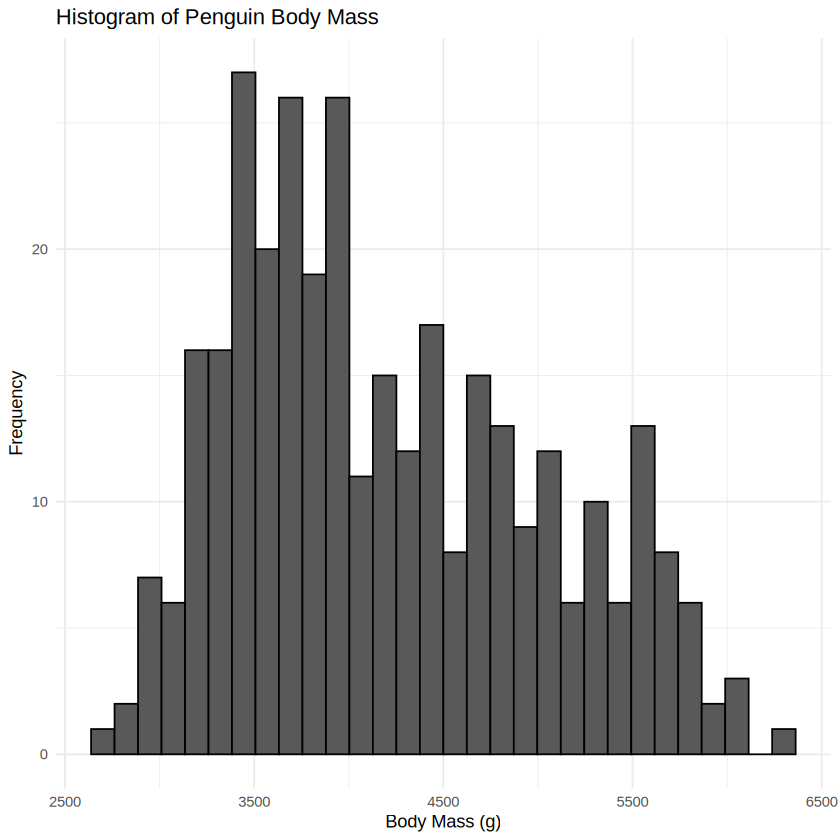

In [64]:
ggplot(
  penguins_clean,
  aes(x = body_mass_g)
) +
  geom_histogram(
    bins = 30,
    color = "black"
  ) +
  labs(
    title = "Histogram of Penguin Body Mass",
    x = "Body Mass (g)",
    y = "Frequency"
  ) +
  theme_minimal()

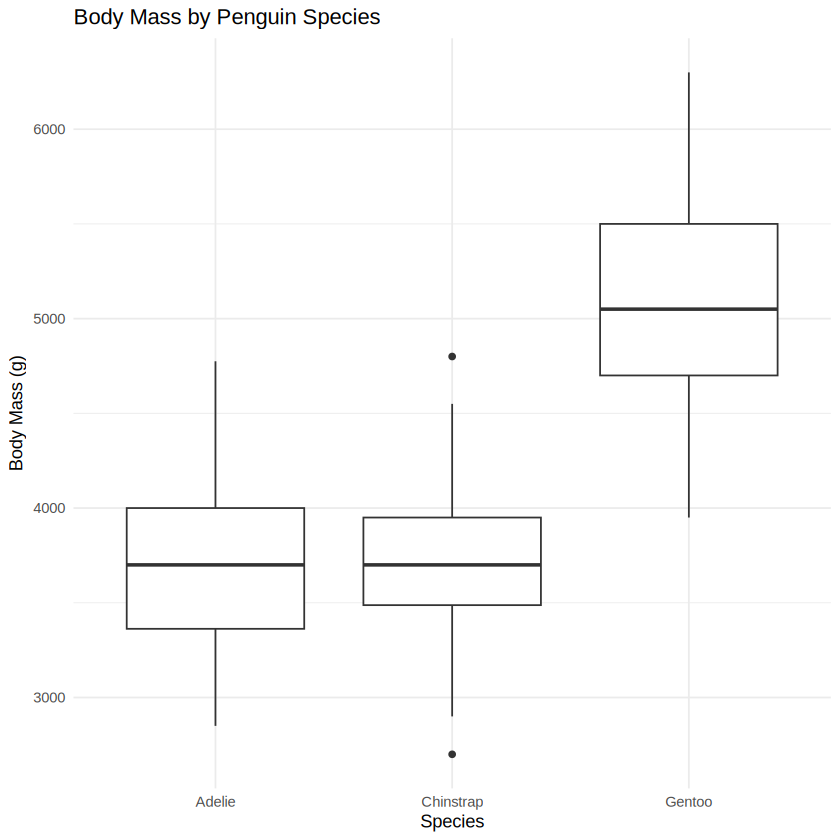

In [65]:
ggplot(
  penguins_clean,
  aes(
    x = species,
    y = body_mass_g
  )
) +
  geom_boxplot() +
  labs(
    title = "Body Mass by Penguin Species",
    x = "Species",
    y = "Body Mass (g)"
  ) +
  theme_minimal()

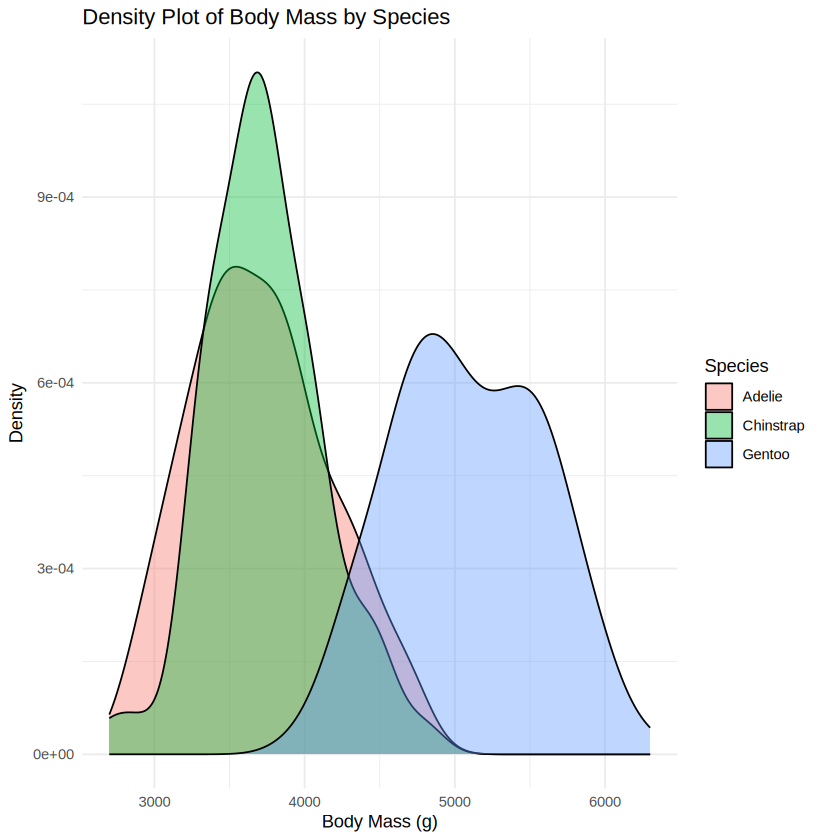

In [66]:
ggplot(
  penguins_clean,
  aes(
    x = body_mass_g,
    fill = species
  )
) +
  geom_density(alpha = 0.4) +
  labs(
    title = "Density Plot of Body Mass by Species",
    x = "Body Mass (g)",
    y = "Density",
    fill = "Species"
  ) +
  theme_minimal()

In [67]:
cat("H0: Male and female penguins have the same mean body mass.\n\n")

cat("H1: Male and female penguins have different mean body masses.\n")

H0: Male and female penguins have the same mean body mass.

H1: Male and female penguins have different mean body masses.


In [68]:
male <- penguins_clean$body_mass_g[
  penguins_clean$sex == "male"
]

female <- penguins_clean$body_mass_g[
  penguins_clean$sex == "female"
]

cat("Number of males:", length(male), "\n")
cat("Number of females:", length(female), "\n")

Number of males: 168 
Number of females: 165 


In [69]:
cat(
  "Male Mean Body Mass:",
  mean(male),
  "g\n"
)

cat(
  "Female Mean Body Mass:",
  mean(female),
  "g\n"
)

cat(
  "Male Standard Deviation:",
  sd(male),
  "g\n"
)

cat(
  "Female Standard Deviation:",
  sd(female),
  "g\n"
)

Male Mean Body Mass: 4545.685 g
Female Mean Body Mass: 3862.273 g
Male Standard Deviation: 787.6289 g
Female Standard Deviation: 666.172 g


In [70]:
male_shapiro <- shapiro.test(male)

female_shapiro <- shapiro.test(female)

cat("Male Shapiro-Wilk Test:\n")
print(male_shapiro)

cat("\nFemale Shapiro-Wilk Test:\n")
print(female_shapiro)

Male Shapiro-Wilk Test:

	Shapiro-Wilk normality test

data:  male
W = 0.92504, p-value = 1.227e-07


Female Shapiro-Wilk Test:

	Shapiro-Wilk normality test

data:  female
W = 0.91931, p-value = 6.155e-08



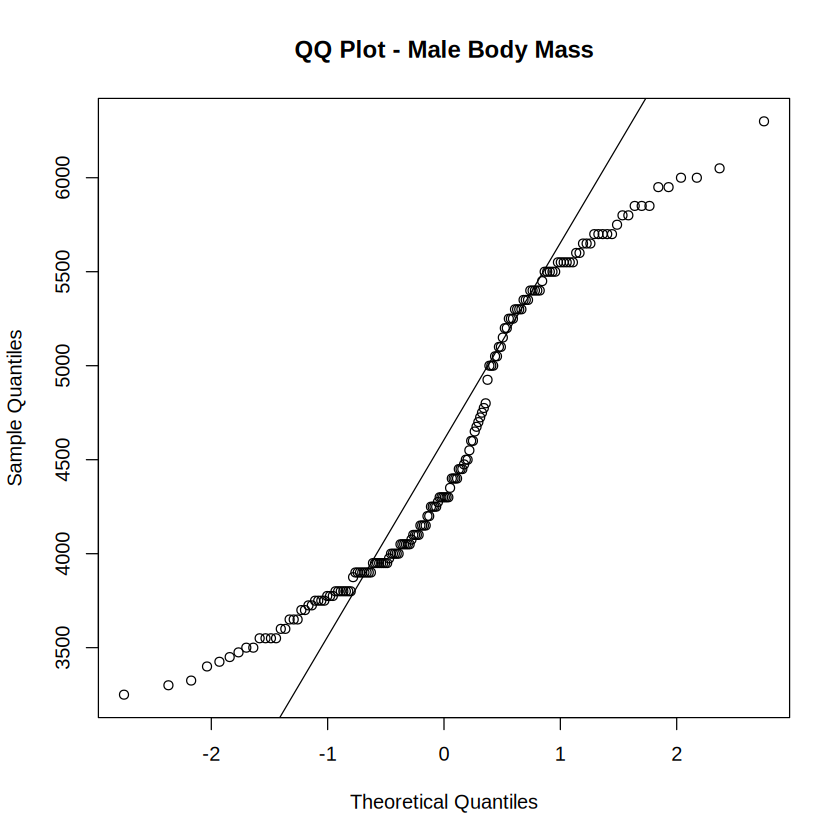

In [71]:
qqnorm(
  male,
  main = "QQ Plot - Male Body Mass"
)

qqline(male)

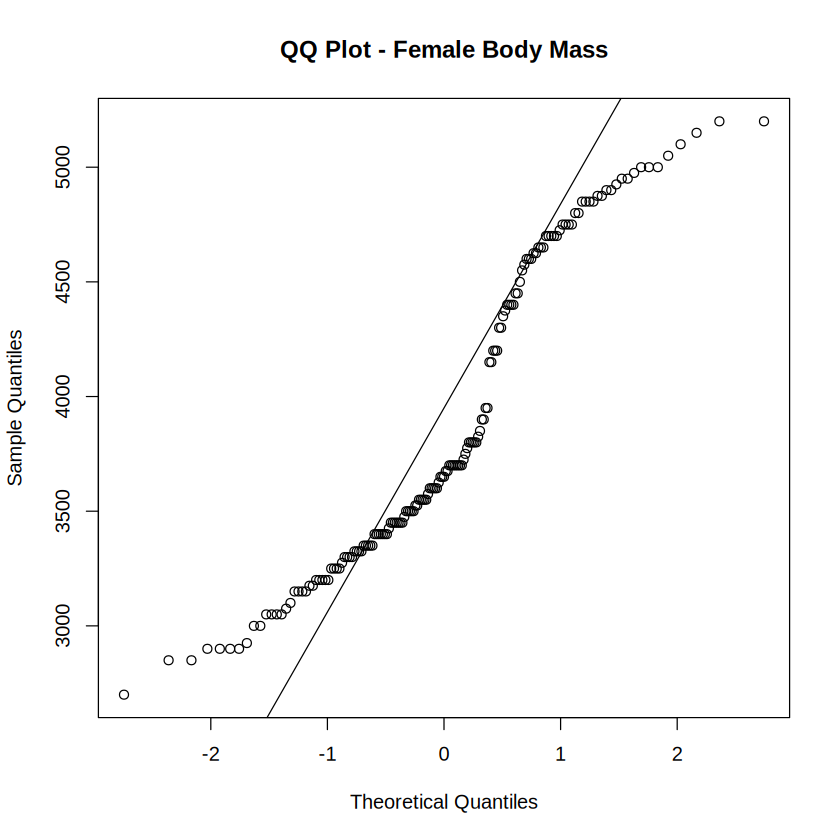

In [72]:
qqnorm(
  female,
  main = "QQ Plot - Female Body Mass"
)

qqline(female)

In [73]:
t_test_result <- t.test(
  male,
  female,
  alternative = "two.sided",
  var.equal = FALSE
)

t_test_result


	Welch Two Sample t-test

data:  male and female
t = 8.5545, df = 323.9, p-value = 4.794e-16
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 526.2453 840.5783
sample estimates:
mean of x mean of y 
 4545.685  3862.273 


In [74]:
cat(
  "t-statistic:",
  t_test_result$statistic,
  "\n"
)

cat(
  "Degrees of freedom:",
  t_test_result$parameter,
  "\n"
)

cat(
  "p-value:",
  t_test_result$p.value,
  "\n"
)

t-statistic: 8.554537 
Degrees of freedom: 323.8959 
p-value: 4.793891e-16 


In [75]:
cat(
  "95% Confidence Interval:\n"
)

cat(
  "Lower:",
  t_test_result$conf.int[1],
  "\n"
)

cat(
  "Upper:",
  t_test_result$conf.int[2],
  "\n"
)

95% Confidence Interval:
Lower: 526.2453 
Upper: 840.5783 


In [76]:
n_male <- length(male)
n_female <- length(female)

pooled_sd <- sqrt(
  (
    (n_male - 1) * var(male) +
    (n_female - 1) * var(female)
  ) /
  (n_male + n_female - 2)
)

cohens_d <- (
  mean(male) - mean(female)
) / pooled_sd

cat("Cohen's d:", cohens_d, "\n")

Cohen's d: 0.9362048 


In [77]:
if (abs(cohens_d) < 0.2) {
  cat("Effect size: Negligible")
} else if (abs(cohens_d) < 0.5) {
  cat("Effect size: Small")
} else if (abs(cohens_d) < 0.8) {
  cat("Effect size: Medium")
} else {
  cat("Effect size: Large")
}

Effect size: Large

In [78]:
if (t_test_result$p.value < 0.05) {

  cat(
    "Conclusion: Reject H0.\n",
    "There is a statistically significant difference ",
    "between male and female mean body masses."
  )

} else {

  cat(
    "Conclusion: Fail to reject H0.\n",
    "There is no statistically significant difference ",
    "between male and female mean body masses."
  )
}

Conclusion: Reject H0.
 There is a statistically significant difference  between male and female mean body masses.

In [79]:
anova_model <- aov(
  body_mass_g ~ species,
  data = penguins_clean
)

summary(anova_model)

             Df    Sum Sq  Mean Sq F value Pr(>F)    
species       2 145190219 72595110   341.9 <2e-16 ***
Residuals   330  70069447   212332                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

In [80]:
for (sp in species_list) {

  x <- penguins_clean$body_mass_g[
    penguins_clean$species == sp
  ]

  cat("\nSpecies:", sp, "\n")
  print(shapiro.test(x))
}


Species: Adelie 

	Shapiro-Wilk normality test

data:  x
W = 0.98116, p-value = 0.04232


Species: Gentoo 

	Shapiro-Wilk normality test

data:  x
W = 0.98606, p-value = 0.2605


Species: Chinstrap 

	Shapiro-Wilk normality test

data:  x
W = 0.98449, p-value = 0.5605



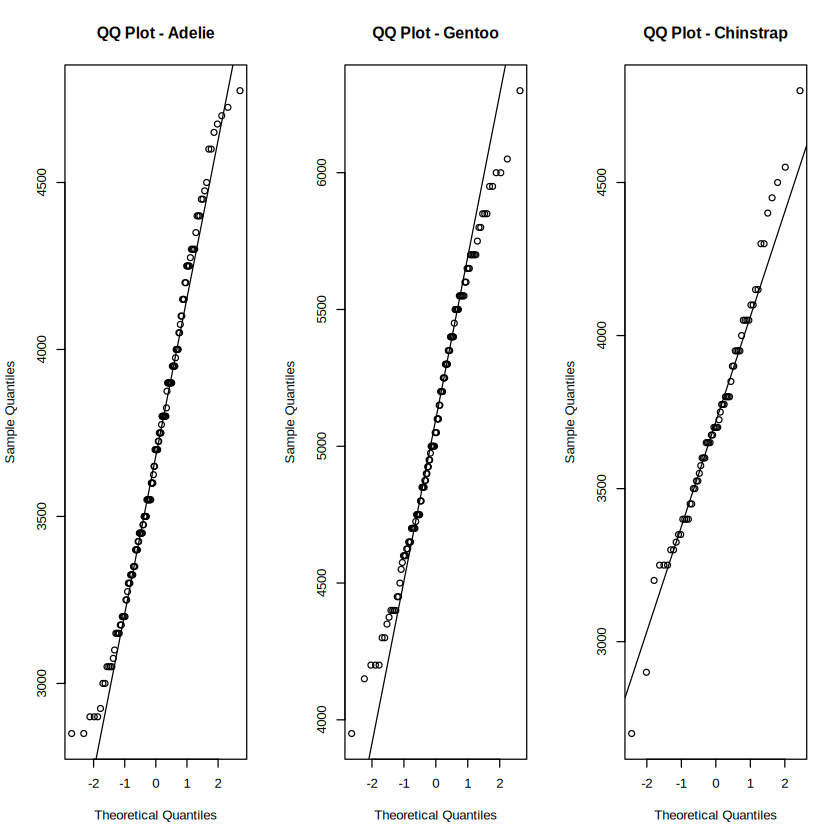

In [81]:
par(mfrow = c(1, 3))

for (sp in species_list) {

  x <- penguins_clean$body_mass_g[
    penguins_clean$species == sp
  ]

  qqnorm(
    x,
    main = paste("QQ Plot -", sp)
  )

  qqline(x)
}

par(mfrow = c(1, 1))

In [82]:
group_medians <- tapply(
  penguins_clean$body_mass_g,
  penguins_clean$species,
  median
)

deviations <- abs(
  penguins_clean$body_mass_g -
  group_medians[
    as.character(penguins_clean$species)
  ]
)

levene_data <- data.frame(
  deviations = deviations,
  species = penguins_clean$species
)

levene_model <- aov(
  deviations ~ species,
  data = levene_data
)

summary(levene_model)

             Df   Sum Sq Mean Sq F value  Pr(>F)   
species       2   716555  358277   5.135 0.00637 **
Residuals   330 23025093   69773                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

In [83]:
anova_table <- summary(anova_model)[[1]]

F_value <- anova_table$`F value`[1]

df_between <- anova_table$Df[1]

df_within <- anova_table$Df[2]

anova_p_value <- anova_table$`Pr(>F)`[1]

cat("F-statistic:", F_value, "\n")
cat("Between-group DF:", df_between, "\n")
cat("Within-group DF:", df_within, "\n")
cat("p-value:", anova_p_value, "\n")

F-statistic: 341.8949 
Between-group DF: 2 
Within-group DF: 330 
p-value: 3.744505e-81 


In [84]:
if (anova_p_value < 0.05) {

  cat(
    "Conclusion: Reject H0.\n",
    "There is a statistically significant difference ",
    "in mean body mass among penguin species."
  )

} else {

  cat(
    "Conclusion: Fail to reject H0.\n",
    "There is no statistically significant difference ",
    "in mean body mass among penguin species."
  )
}

Conclusion: Reject H0.
 There is a statistically significant difference  in mean body mass among penguin species.

In [85]:
tukey_result <- TukeyHSD(anova_model)

tukey_result

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = body_mass_g ~ species, data = penguins_clean)

$species
                       diff       lwr       upr    p adj
Chinstrap-Adelie   26.92385 -132.3528  186.2005 0.916431
Gentoo-Adelie    1386.27259 1252.2897 1520.2554 0.000000
Gentoo-Chinstrap 1359.34874 1194.4304 1524.2671 0.000000


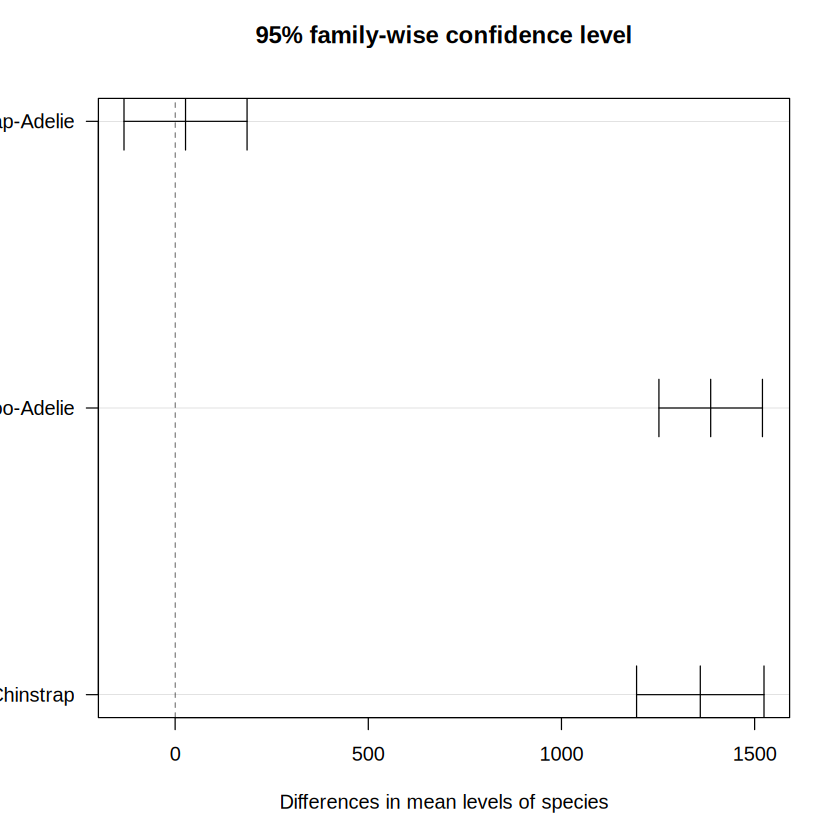

In [86]:
plot(
  tukey_result,
  las = 1
)

In [87]:
tukey_table <- as.data.frame(
  tukey_result$species
)

tukey_table
tukey_table[
  tukey_table$`p adj` < 0.05,
]

,diff,lwr,upr,p adj
,<dbl>,<dbl>,<dbl>,<dbl>
Chinstrap-Adelie,26.92385,-132.3528,186.2005,9.164310e-01
Gentoo-Adelie,1386.27259,1252.2897,1520.2554,5.818679e-13
Gentoo-Chinstrap,1359.34874,1194.4304,1524.2671,5.818679e-13


,diff,lwr,upr,p adj
,<dbl>,<dbl>,<dbl>,<dbl>
Gentoo-Adelie,1386.273,1252.29,1520.255,5.818679e-13
Gentoo-Chinstrap,1359.349,1194.43,1524.267,5.818679e-13


In [88]:
kruskal_result <- kruskal.test(
  body_mass_g ~ species,
  data = penguins_clean
)

kruskal_result


	Kruskal-Wallis rank sum test

data:  body_mass_g by species
Kruskal-Wallis chi-squared = 212.09, df = 2, p-value < 2.2e-16


In [89]:
cat(
  "ANOVA p-value:",
  anova_p_value,
  "\n"
)

cat(
  "Kruskal-Wallis p-value:",
  kruskal_result$p.value,
  "\n\n"
)

if (
  anova_p_value < 0.05 &&
  kruskal_result$p.value < 0.05
) {

  cat(
    "Both tests indicate significant differences ",
    "among penguin species."
  )

} else if (
  anova_p_value >= 0.05 &&
  kruskal_result$p.value >= 0.05
) {

  cat(
    "Both tests indicate no significant differences ",
    "among penguin species."
  )

} else {

  cat(
    "The two tests give different conclusions."
  )
}

ANOVA p-value: 3.744505e-81 
Kruskal-Wallis p-value: 8.836877e-47 

Both tests indicate significant differences  among penguin species.

In [90]:
two_way_model <- aov(
  body_mass_g ~ species * sex,
  data = penguins_clean
)

summary(two_way_model)

             Df    Sum Sq  Mean Sq F value   Pr(>F)    
species       2 145190219 72595110 758.358  < 2e-16 ***
sex           1  37090262 37090262 387.460  < 2e-16 ***
species:sex   2   1676557   838278   8.757 0.000197 ***
Residuals   327  31302628    95727                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

In [91]:
two_way_table <- summary(two_way_model)[[1]]

two_way_table

,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
species,2,145190219,72595109.56,758.358072,1.540207e-123
sex,1,37090262,37090261.78,387.459976,1.902273e-57
species:sex,2,1676557,838278.37,8.756997,1.973489e-04
Residuals,327,31302628,95726.69,NA,NA


In [92]:
species_p <- two_way_table$`Pr(>F)`[1]

sex_p <- two_way_table$`Pr(>F)`[2]

interaction_p <- two_way_table$`Pr(>F)`[3]

cat(
  "Species p-value:",
  species_p,
  "\n"
)

cat(
  "Sex p-value:",
  sex_p,
  "\n"
)

cat(
  "Species × Sex interaction p-value:",
  interaction_p,
  "\n"
)

Species p-value: 1.540207e-123 
Sex p-value: 1.902273e-57 
Species × Sex interaction p-value: 0.0001973489 


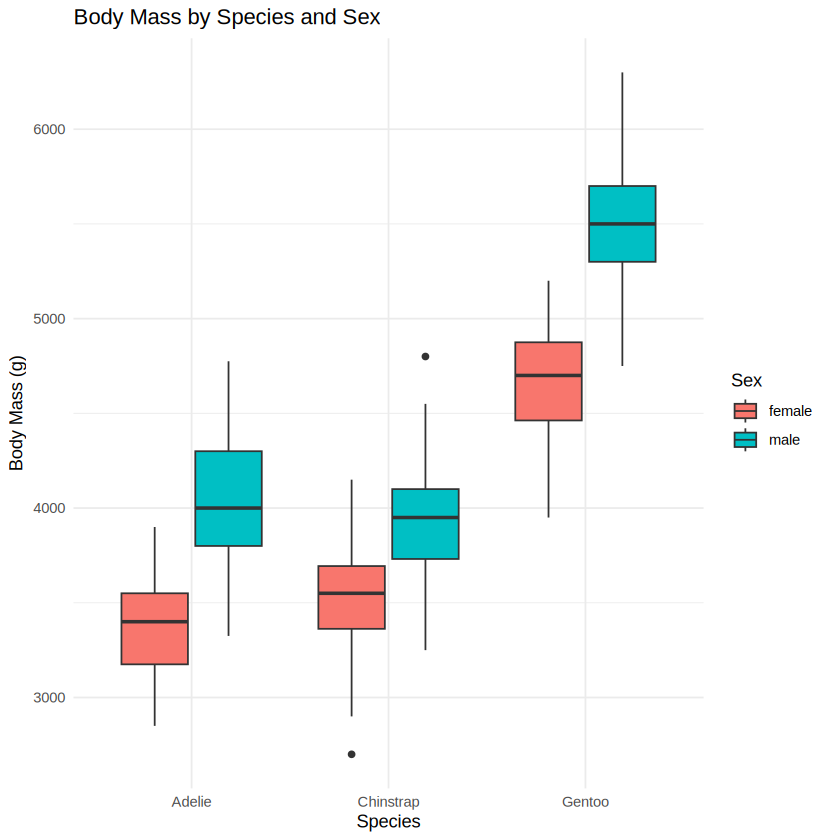

In [93]:
ggplot(
  penguins_clean,
  aes(
    x = species,
    y = body_mass_g,
    fill = sex
  )
) +
  geom_boxplot() +
  labs(
    title = "Body Mass by Species and Sex",
    x = "Species",
    y = "Body Mass (g)",
    fill = "Sex"
  ) +
  theme_minimal()

In [94]:
interaction_data <- aggregate(
  body_mass_g ~ species + sex,
  data = penguins_clean,
  FUN = mean
)

interaction_data

species,sex,body_mass_g
<chr>,<chr>,<dbl>
Adelie,female,3368.836
Chinstrap,female,3527.206
Gentoo,female,4679.741
Adelie,male,4043.493
Chinstrap,male,3938.971
Gentoo,male,5484.836


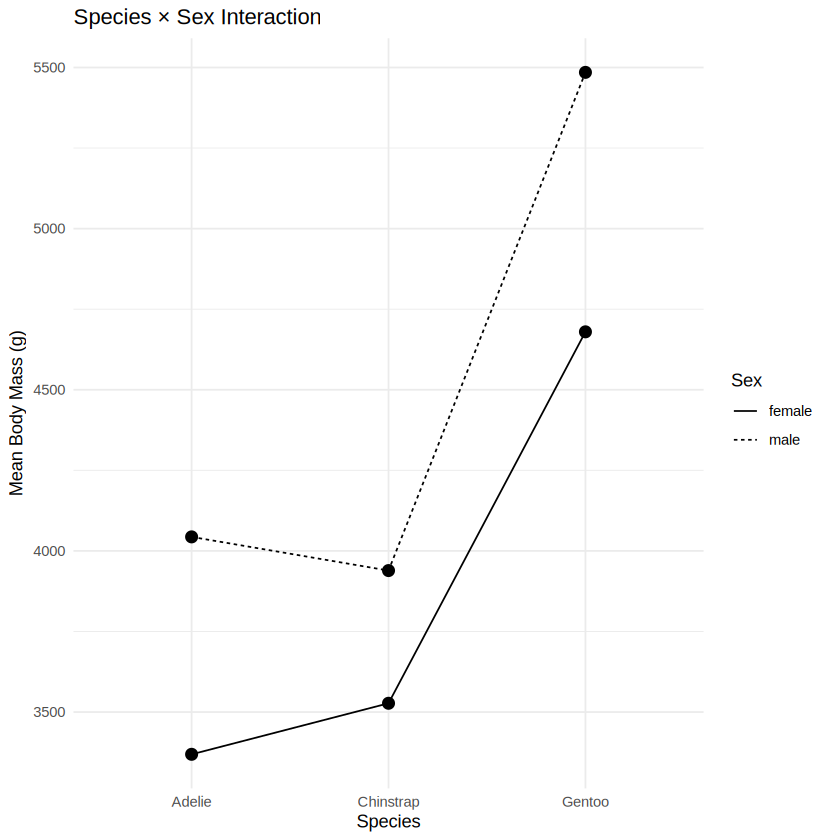

In [95]:
ggplot(
  interaction_data,
  aes(
    x = species,
    y = body_mass_g,
    group = sex,
    linetype = sex
  )
) +
  geom_point(size = 3) +
  geom_line() +
  labs(
    title = "Species × Sex Interaction",
    x = "Species",
    y = "Mean Body Mass (g)",
    linetype = "Sex"
  ) +
  theme_minimal()

In [96]:
flipper <- penguins_clean$flipper_length_mm

cat("Mean:", mean(flipper), "\n")
cat("Median:", median(flipper), "\n")
cat("Minimum:", min(flipper), "\n")
cat("Maximum:", max(flipper), "\n")
cat("Variance:", var(flipper), "\n")
cat("Standard Deviation:", sd(flipper), "\n")
cat("IQR:", IQR(flipper), "\n")
cat("Skewness:", skewness(flipper), "\n")
cat("Kurtosis:", kurtosis(flipper), "\n")

Mean: 200.967 
Median: 197 
Minimum: 172 
Maximum: 231 
Variance: 196.4417 
Standard Deviation: 14.01577 
IQR: 23 
Skewness: 0.3585237 
Kurtosis: 2.035167 


In [97]:
flipper_species_stats <- data.frame()

for (sp in species_list) {

  x <- penguins_clean$flipper_length_mm[
    penguins_clean$species == sp
  ]

  temp <- data.frame(
    Species = sp,
    Count = length(x),
    Mean = mean(x),
    Median = median(x),
    SD = sd(x),
    Minimum = min(x),
    Maximum = max(x),
    IQR = IQR(x)
  )

  flipper_species_stats <- rbind(
    flipper_species_stats,
    temp
  )
}

flipper_species_stats

Species,Count,Mean,Median,SD,Minimum,Maximum,IQR
<chr>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>
Adelie,146,190.1027,190,6.521825,172,210,9.0
Gentoo,119,217.2353,216,6.585431,203,231,9.5
Chinstrap,68,195.8235,196,7.131894,178,212,10.0


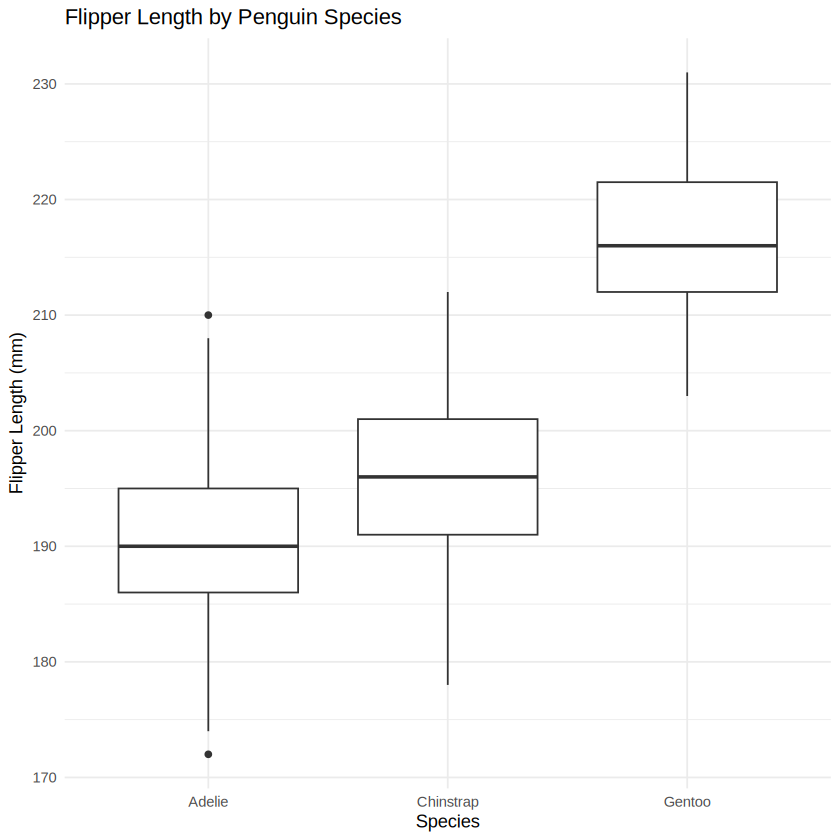

In [98]:
ggplot(
  penguins_clean,
  aes(
    x = species,
    y = flipper_length_mm
  )
) +
  geom_boxplot() +
  labs(
    title = "Flipper Length by Penguin Species",
    x = "Species",
    y = "Flipper Length (mm)"
  ) +
  theme_minimal()

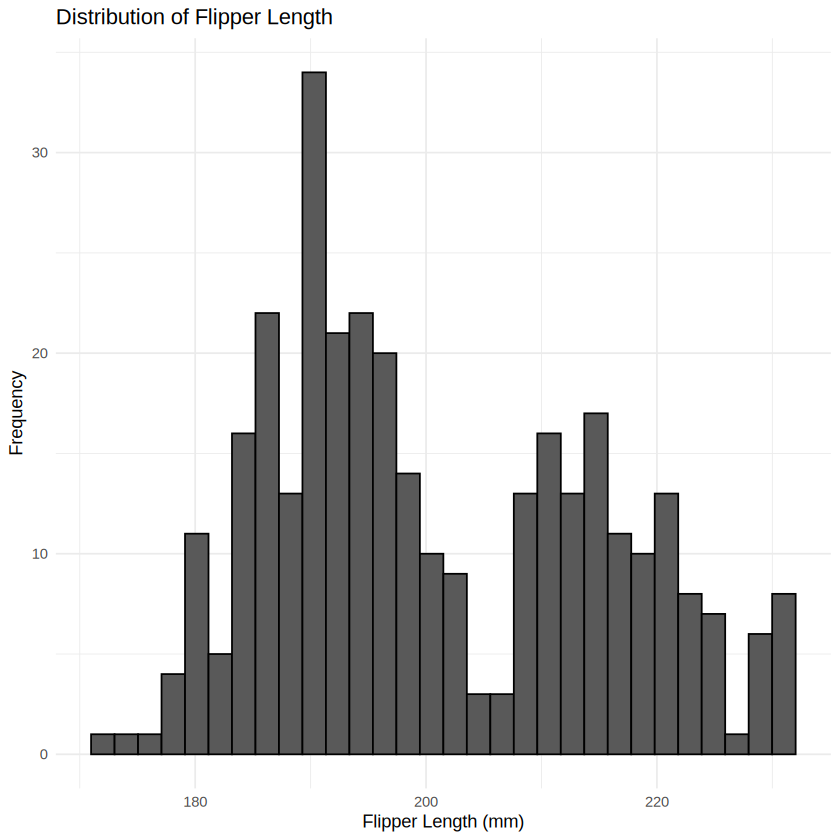

In [99]:
ggplot(
  penguins_clean,
  aes(x = flipper_length_mm)
) +
  geom_histogram(
    bins = 30,
    color = "black"
  ) +
  labs(
    title = "Distribution of Flipper Length",
    x = "Flipper Length (mm)",
    y = "Frequency"
  ) +
  theme_minimal()

In [100]:
flipper_anova <- aov(
  flipper_length_mm ~ species,
  data = penguins_clean
)

summary(flipper_anova)

             Df Sum Sq Mean Sq F value Pr(>F)    
species       2  50526   25263   567.4 <2e-16 ***
Residuals   330  14693      45                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

In [101]:
flipper_table <- summary(flipper_anova)[[1]]

flipper_F <- flipper_table$`F value`[1]

flipper_p <- flipper_table$`Pr(>F)`[1]

cat(
  "F-statistic:",
  flipper_F,
  "\n"
)

cat(
  "p-value:",
  flipper_p,
  "\n"
)

F-statistic: 567.407 
p-value: 1.587418e-107 


In [102]:
flipper_tukey <- TukeyHSD(
  flipper_anova
)

flipper_tukey

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = flipper_length_mm ~ species, data = penguins_clean)

$species
                     diff       lwr       upr p adj
Chinstrap-Adelie  5.72079  3.414364  8.027215     0
Gentoo-Adelie    27.13255 25.192399 29.072709     0
Gentoo-Chinstrap 21.41176 19.023644 23.799885     0


In [103]:
flipper_kruskal <- kruskal.test(
  flipper_length_mm ~ species,
  data = penguins_clean
)

flipper_kruskal


	Kruskal-Wallis rank sum test

data:  flipper_length_mm by species
Kruskal-Wallis chi-squared = 237.35, df = 2, p-value < 2.2e-16


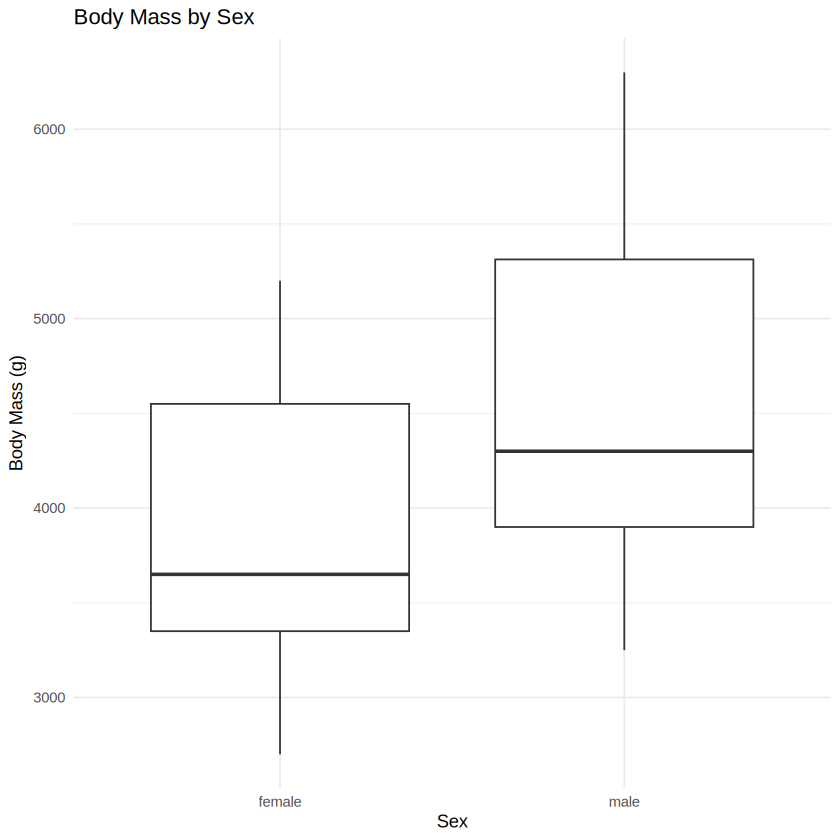

In [104]:
ggplot(
  penguins_clean,
  aes(
    x = sex,
    y = body_mass_g
  )
) +
  geom_boxplot() +
  labs(
    title = "Body Mass by Sex",
    x = "Sex",
    y = "Body Mass (g)"
  ) +
  theme_minimal()

In [105]:
mean_species <- aggregate(
  body_mass_g ~ species,
  data = penguins_clean,
  FUN = mean
)

mean_species

species,body_mass_g
<chr>,<dbl>
Adelie,3706.164
Chinstrap,3733.088
Gentoo,5092.437


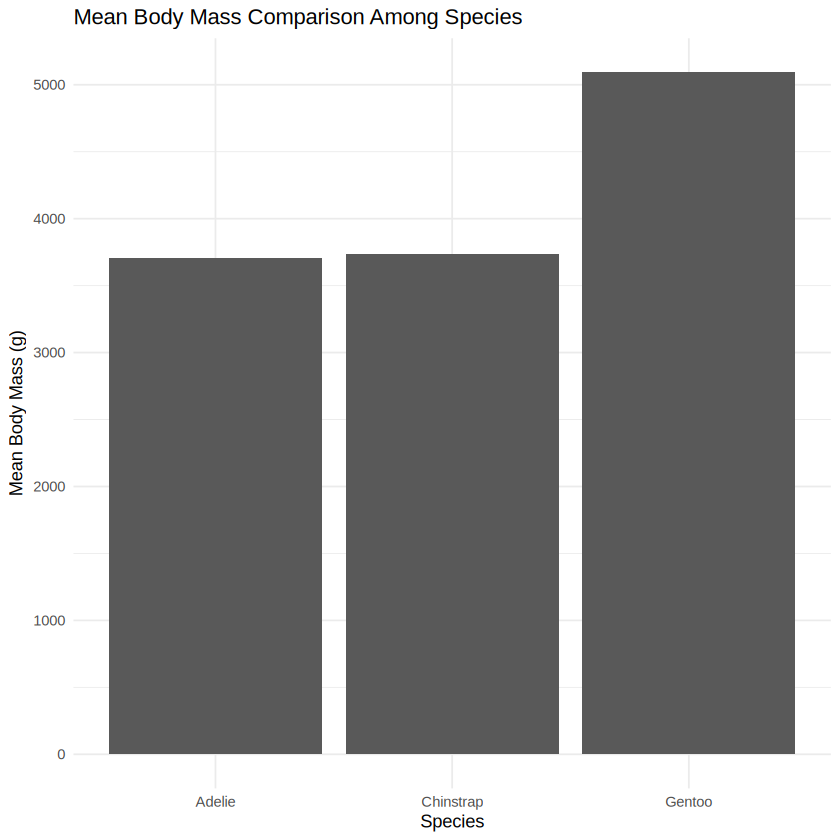

In [106]:
ggplot(
  mean_species,
  aes(
    x = species,
    y = body_mass_g
  )
) +
  geom_col() +
  labs(
    title = "Mean Body Mass Comparison Among Species",
    x = "Species",
    y = "Mean Body Mass (g)"
  ) +
  theme_minimal()

In [107]:
cat("============================================\n")
cat("       FINAL STATISTICAL SUMMARY\n")
cat("       PALMER PENGUINS DATASET\n")
cat("============================================\n\n")

cat("DESCRIPTIVE STATISTICS\n")
cat("--------------------------------------------\n")

cat(
  "Mean Body Mass:",
  round(mean(body_mass), 2),
  "g\n"
)

cat(
  "Median Body Mass:",
  round(median(body_mass), 2),
  "g\n"
)

cat(
  "Standard Deviation:",
  round(sd(body_mass), 2),
  "g\n"
)

cat(
  "IQR:",
  round(IQR(body_mass), 2),
  "g\n\n"
)


cat("MALE VS FEMALE T-TEST\n")
cat("--------------------------------------------\n")

cat(
  "t-statistic:",
  round(t_test_result$statistic, 3),
  "\n"
)

cat(
  "p-value:",
  format.pval(t_test_result$p.value),
  "\n"
)

cat(
  "Cohen's d:",
  round(cohens_d, 3),
  "\n\n"
)


cat("ONE-WAY ANOVA\n")
cat("--------------------------------------------\n")

cat(
  "F-statistic:",
  round(F_value, 3),
  "\n"
)

cat(
  "Degrees of freedom:",
  df_between,
  ",",
  df_within,
  "\n"
)

cat(
  "p-value:",
  format.pval(anova_p_value),
  "\n\n"
)


cat("KRUSKAL-WALLIS TEST\n")
cat("--------------------------------------------\n")

cat(
  "Chi-squared:",
  round(kruskal_result$statistic, 3),
  "\n"
)

cat(
  "p-value:",
  format.pval(kruskal_result$p.value),
  "\n\n"
)


cat("TWO-WAY ANOVA\n")
cat("--------------------------------------------\n")

cat(
  "Species p-value:",
  format.pval(species_p),
  "\n"
)

cat(
  "Sex p-value:",
  format.pval(sex_p),
  "\n"
)

cat(
  "Species × Sex p-value:",
  format.pval(interaction_p),
  "\n\n"
)


cat("FLIPPER LENGTH ANOVA\n")
cat("--------------------------------------------\n")

cat(
  "F-statistic:",
  round(flipper_F, 3),
  "\n"
)

cat(
  "p-value:",
  format.pval(flipper_p),
  "\n"
)

cat("============================================\n")

       FINAL STATISTICAL SUMMARY
       PALMER PENGUINS DATASET

DESCRIPTIVE STATISTICS
--------------------------------------------
Mean Body Mass: 4207.06 g
Median Body Mass: 4050 g
Standard Deviation: 805.22 g
IQR: 1225 g

MALE VS FEMALE T-TEST
--------------------------------------------
t-statistic: 8.555 
p-value: 4.7939e-16 
Cohen's d: 0.936 

ONE-WAY ANOVA
--------------------------------------------
F-statistic: 341.895 
Degrees of freedom: 2 , 330 
p-value: < 2.22e-16 

KRUSKAL-WALLIS TEST
--------------------------------------------
Chi-squared: 212.085 
p-value: < 2.22e-16 

TWO-WAY ANOVA
--------------------------------------------
Species p-value: < 2.22e-16 
Sex p-value: < 2.22e-16 
Species × Sex p-value: 0.00019735 

FLIPPER LENGTH ANOVA
--------------------------------------------
F-statistic: 567.407 
p-value: < 2.22e-16 


In [108]:
cat("FINAL CONCLUSION\n")
cat("================\n\n")

if (t_test_result$p.value < 0.05) {
  cat(
    "1. Male and female penguins have significantly different ",
    "mean body masses.\n"
  )
} else {
  cat(
    "1. Male and female penguins do not have a statistically ",
    "significant difference in mean body mass.\n"
  )
}


if (anova_p_value < 0.05) {
  cat(
    "2. Mean body mass differs significantly among penguin species.\n"
  )
} else {
  cat(
    "2. Mean body mass does not differ significantly among species.\n"
  )
}


if (kruskal_result$p.value < 0.05) {
  cat(
    "3. Kruskal-Wallis also indicates significant differences ",
    "among species.\n"
  )
} else {
  cat(
    "3. Kruskal-Wallis does not indicate significant differences ",
    "among species.\n"
  )
}


if (species_p < 0.05) {
  cat(
    "4. Species has a significant effect on body mass.\n"
  )
} else {
  cat(
    "4. Species does not have a significant effect on body mass.\n"
  )
}


if (sex_p < 0.05) {
  cat(
    "5. Sex has a significant effect on body mass.\n"
  )
} else {
  cat(
    "5. Sex does not have a significant effect on body mass.\n"
  )
}


if (interaction_p < 0.05) {
  cat(
    "6. There is a significant Species × Sex interaction.\n"
  )
} else {
  cat(
    "6. There is no significant Species × Sex interaction.\n"
  )
}


if (flipper_p < 0.05) {
  cat(
    "7. Flipper length differs significantly among species.\n"
  )
} else {
  cat(
    "7. Flipper length does not differ significantly among species.\n"
  )
}

FINAL CONCLUSION

1. Male and female penguins have significantly different  mean body masses.
2. Mean body mass differs significantly among penguin species.
3. Kruskal-Wallis also indicates significant differences  among species.
4. Species has a significant effect on body mass.
5. Sex has a significant effect on body mass.
6. There is a significant Species × Sex interaction.
7. Flipper length differs significantly among species.
